In [10]:
pip install scikit_posthocs

Note: you may need to restart the kernel to use updated packages.


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp
from scipy.stats import poisson, chi2


In [4]:
df_arrivals = pd.read_csv("data_csvs/Data_Arrivals.csv")
print(df_arrivals.shape)
df_arrivals.head()

(100, 25)


,Unnamed: 0,1am,2am,3am,4am,5am,6am,7am,8am,9am,...,3pm,4pm,5pm,6pm,7pm,8pm,9pm,10pm,11pm,12am
0,Day1,0,0,2,1,0,0,0,2,1,...,3,2,1,7,4,5,2,3,4,2
1,Day2,3,2,1,0,0,0,0,0,3,...,3,4,6,6,2,2,3,2,3,3
2,Day3,1,0,2,1,0,1,1,2,3,...,4,5,8,7,4,3,1,2,2,4
3,Day4,1,0,0,1,0,2,0,5,2,...,4,2,3,8,4,8,3,3,3,5
4,Day5,1,2,0,1,1,1,2,1,1,...,8,2,10,5,6,2,3,3,4,3


In [5]:
df_arrivals = df_arrivals.rename(columns={"Unnamed: 0": "Day"})
df_arrivals = df_arrivals.set_index("Day")
df_arrivals.head()

,1am,2am,3am,4am,5am,6am,7am,8am,9am,10am,...,3pm,4pm,5pm,6pm,7pm,8pm,9pm,10pm,11pm,12am
Day,,,,,,,,,,,,,,,,,,,,,
Day1,0,0,2,1,0,0,0,2,1,4,...,3,2,1,7,4,5,2,3,4,2
Day2,3,2,1,0,0,0,0,0,3,1,...,3,4,6,6,2,2,3,2,3,3
Day3,1,0,2,1,0,1,1,2,3,0,...,4,5,8,7,4,3,1,2,2,4
Day4,1,0,0,1,0,2,0,5,2,2,...,4,2,3,8,4,8,3,3,3,5
Day5,1,2,0,1,1,1,2,1,1,1,...,8,2,10,5,6,2,3,3,4,3


# Visualize Data

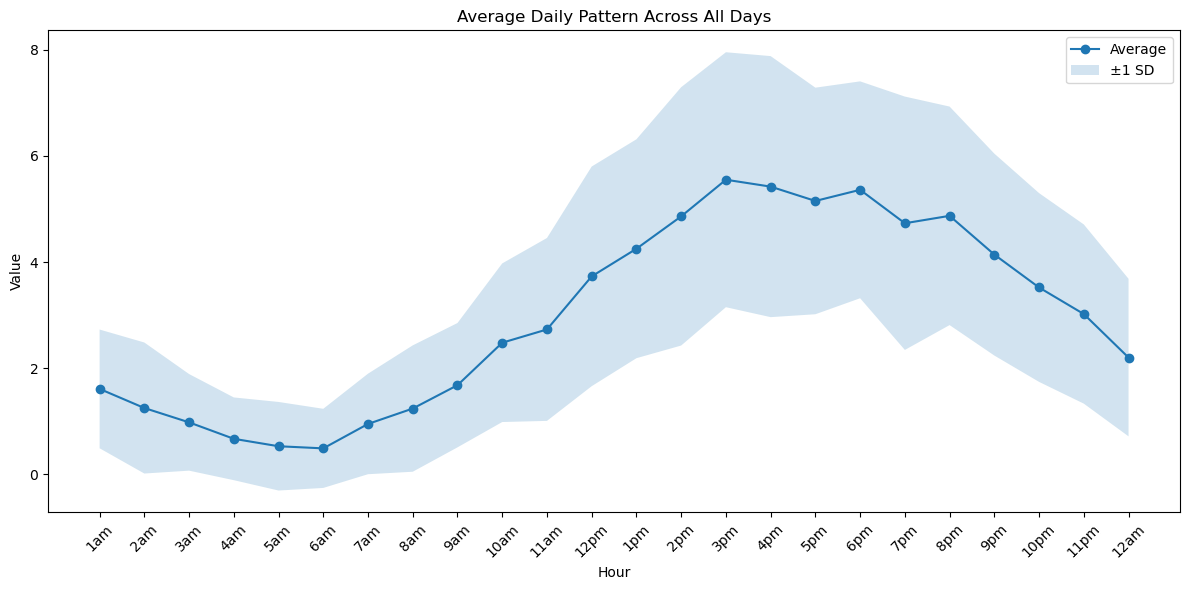

In [ ]:
hourly_mean = df_arrivals.mean()
hourly_std = df_arrivals.std()

plt.figure(figsize=(12, 6))
plt.plot(hourly_mean.index, hourly_mean.values, label='Average', marker='o')
plt.fill_between(hourly_mean.index,
                 hourly_mean - hourly_std,
                 hourly_mean + hourly_std,
                 alpha=0.2, label='±1 SD')

plt.title("Average Daily Pattern Across All Days")
plt.xlabel("Hour")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Differences by hour

It is quite evident that the distribution of arrivals differs by hour. To explore thsi further, we look at the box plots of arrivals for each hour of the day. 

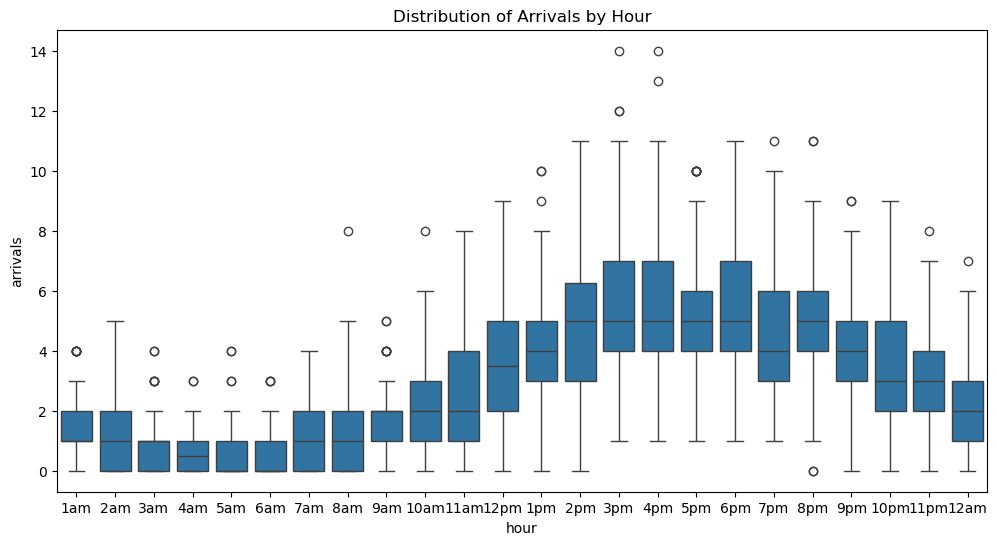

In [7]:
df_melt = df_arrivals.melt(var_name='hour', value_name='arrivals')
plt.figure(figsize=(12,6))
sns.boxplot(x='hour', y='arrivals', data=df_melt)
plt.title('Distribution of Arrivals by Hour')
plt.show()

## Statistical tests to measure diifferences

### Do distributions differ

To first determine whether the data suggests that there are different underlying arrival distributions, we will perform a **Kruskal-Wallis test**. This will tell us whether at least one hour differs from the others at a statistical signifcance level of p < 0.05. We use the Kruskal-Wallis test because: 
- Non parametric (i.e. does not assume an underlying distribution)
- No normaility assumption unlike ANOVA
- If some hours have small counts or non-normal skew (typical for Poisson counts)

From our results, we reject the null hypothesis H0: All groups (hours) come from the same distribution.

### Which hours differ
The Kruskal-Wallis test told us that there is evidence to suggest that the arrival distribution differs across hours, however it does not indicate which hours differ. Pairwise comparison can be used. 

To determine how to group hours into unique distributions, we want to measure the statistical significance of whether the arrival distributions for two given hours differ. To do so, we use the Dunn's test. The Dunn's test is 
- A nonparametric pairwise comparison method
- It’s essentially the “Mann–Whitney U test” generalized to multiple groups after a Kruskal–Wallis

We use a Bonferroni correction. 
- We are testing 24*23 / 2 = 276 pairwise comparisons, so for an alpha < 0.05, we would expect roughly 14 false positives by chnace alone 
- The Bonferroni correction is given as 
> p_adjusted = p_raw * N_comparisons
- This makes is so that the overall false positive rate stays below 0.05

In [14]:
h_stat, p_val = kruskal(*[df_arrivals[col] for col in df_arrivals.columns])
print(f"Kruskal–Wallis H = {h_stat:.3f}, p = {p_val:.3g}")

if p_val < 0.05:
    print("→ Reject H₀: distributions differ across hours.")
else:
    print("→ Fail to reject H₀: no evidence of difference across hours.")

Kruskal–Wallis H = 1374.672, p = 1.64e-276
→ Reject H₀: distributions differ across hours.


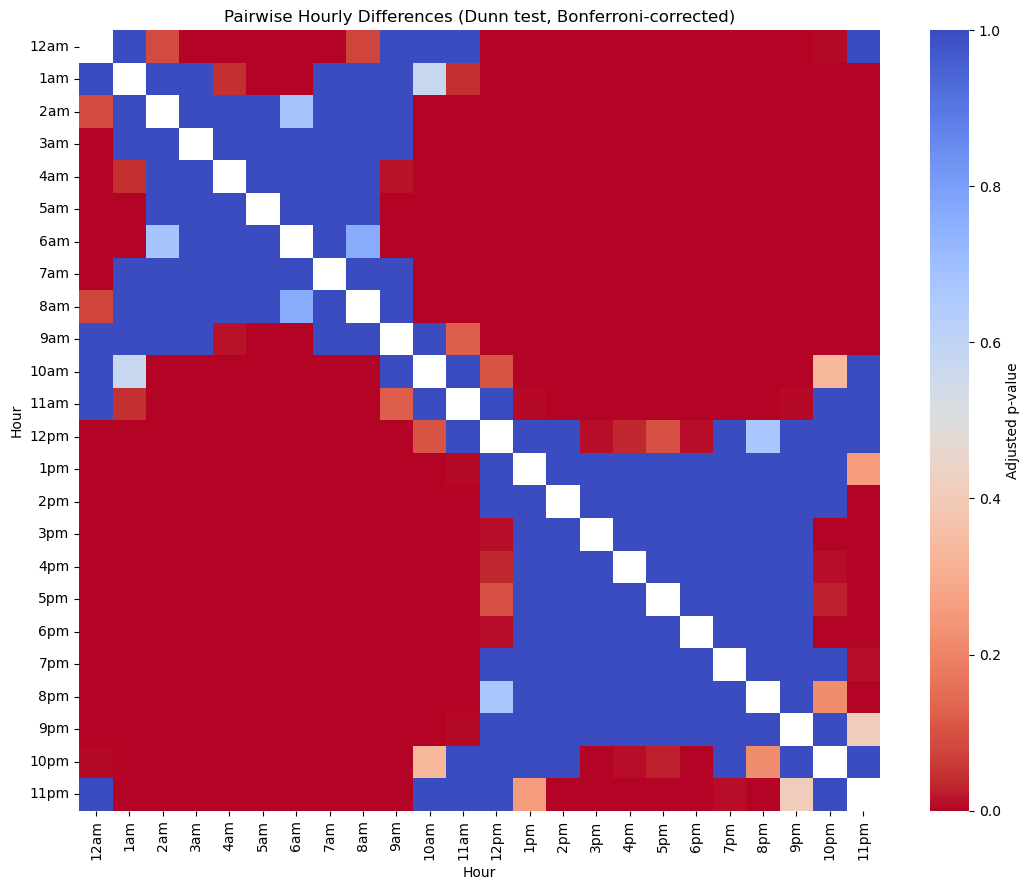

In [ ]:
df_melt = df_arrivals.melt(var_name='hour', value_name='arrivals')

hour_order = ['12am','1am','2am','3am','4am','5am','6am','7am','8am','9am','10am','11am',
              '12pm','1pm','2pm','3pm','4pm','5pm','6pm','7pm','8pm','9pm','10pm','11pm']
df_melt['hour'] = pd.Categorical(df_melt['hour'], categories=hour_order, ordered=True)

# Dunn post-hoc with multiple-testing correction
posthoc = sp.posthoc_dunn(df_melt, val_col='arrivals', group_col='hour', p_adjust='bonferroni')
posthoc = posthoc.loc[hour_order, hour_order]

# Mask the diagonal (self-comparisons are trivial)
mask = np.eye(posthoc.shape[0], dtype=bool)

plt.figure(figsize=(11,9))
sns.heatmap(posthoc, mask=mask, vmin=0, vmax=1, cmap='coolwarm_r',
            cbar_kws={'label': 'Adjusted p-value'})
plt.title('Pairwise Hourly Differences (Dunn test, Bonferroni-corrected)')
plt.xlabel('Hour')
plt.ylabel('Hour')
plt.tight_layout()
plt.show()

The blocks in red have p values < 0.05 which means that there is evidence to suggest that those two hours have different underlying arrival distributions. 

- 1pm - 9pm 
- 10pm, 11pm, 12am, 10am, 11am, 12 pm
- 3am - 6am
- 1am, 2am, 7am, 8am, 9am 

In [12]:
alpha = 0.05
sig_pairs = []
for i in range(len(hour_order)):
    for j in range(i+1, len(hour_order)):
        p = posthoc.iloc[i, j]
        if p < alpha:
            sig_pairs.append((hour_order[i], hour_order[j], float(p)))

# Sort by p-value (strongest differences first)
sig_pairs = sorted(sig_pairs, key=lambda x: x[2])
for a,b,p in sig_pairs[:20]:
    print(f"{a} vs {b}: p={p:.3g}")

6am vs 3pm: p=7.94e-51
6am vs 6pm: p=2.83e-50
5am vs 3pm: p=6.82e-50
5am vs 6pm: p=2.4e-49
6am vs 4pm: p=1.23e-48
5am vs 4pm: p=1.01e-47
6am vs 5pm: p=8.14e-47
5am vs 5pm: p=6.42e-46
4am vs 3pm: p=8.21e-46
4am vs 6pm: p=2.75e-45
4am vs 4pm: p=9.86e-44
6am vs 8pm: p=2.16e-43
5am vs 8pm: p=1.58e-42
4am vs 5pm: p=5.28e-42
6am vs 2pm: p=1.81e-40
5am vs 2pm: p=1.24e-39
6am vs 7pm: p=4.24e-39
7am vs 3pm: p=8.22e-39
4am vs 8pm: p=9.26e-39
7am vs 6pm: p=2.5e-38


# Parameter estimation 
Now that we have hypothesized a distribution from which the observatiosn come from, we now want to estimate the parameters. Since we are looking at a non homogenous poisson process, we can group by the blocks / hours that we theorized to have the same arrivale rate. For each block of time, we will estimate the lambda value based on the data.


In [17]:
blocks = {
    "Block_1pm_9pm":            ['1pm','2pm','3pm','4pm','5pm','6pm','7pm','8pm','9pm'],
    "Block_10pm_11pm_12am_10am_11am_12pm": ['10pm','11pm','12am','10am','11am','12pm'],
    "Block_3am_6am":            ['3am','4am','5am','6am'],
    "Block_1am_2am_7am_8am_9am":['1am','2am','7am','8am','9am'],
}

In [24]:
def poisson_block_estimates(df, blocks):
    rows = []
    for name, hours in blocks.items():
        # Pool all hourly cells in the block across all days
        x = df[hours].to_numpy().ravel()
        n = x.size
        lam_hat = x.mean()      
        se = np.sqrt(lam_hat / n)
        ci_lo = max(0.0, lam_hat - 1.96*se)
        ci_hi = lam_hat + 1.96*se
        rows.append({
            "block": name,
            "hours": ", ".join(hours),
            "lambda_hat_MoM": lam_hat,
            "lambda_hat_MLE": lam_hat,  
            "n_cells": n,       
            "SE(lambda_hat)": se,
            "CI95_low": ci_lo,
            "CI95_high": ci_hi,
            "var_over_mean": x.var(ddof=1)/lam_hat if lam_hat > 0 else np.nan 
        })
    return pd.DataFrame(rows)

estimates = poisson_block_estimates(df_arrivals, blocks)
estimates

,block,hours,lambda_hat_MoM,lambda_hat_MLE,n_cells,SE(lambda_hat),CI95_low,CI95_high,var_over_mean
0,Block_1pm_9pm,"1pm, 2pm, 3pm, 4pm, 5pm, 6pm, 7pm, 8pm, 9pm",4.925556,4.925556,900,0.073979,4.780557,5.070554,1.034312
1,Block_10pm_11pm_12am_10am_11am_12pm,"10pm, 11pm, 12am, 10am, 11am, 12pm",2.946667,2.946667,600,0.070079,2.809311,3.084022,1.092484
2,Block_3am_6am,"3am, 4am, 5am, 6am",0.667500,0.667500,400,0.040850,0.587433,0.747567,1.054237
3,Block_1am_2am_7am_8am_9am,"1am, 2am, 7am, 8am, 9am",1.346000,1.346000,500,0.051884,1.244306,1.447694,1.005193


# Goodness of fit test

Now we compare the observed count frequencies with the expected frequencies from a poisson distribution with the gvien lambda. The Goodness of Fit test will be used for discrete distributions. 
- H0: The data comes from the hypothesized distribution 
- H1: The data does not come from the hypothesized distribution

Hence, if we fail to reject the null hypothesis at p > 0.05, that suggests that the Poissn distribution with the given lambda fits the data adequately.

In [ ]:
def chisq_gof_poisson(x, min_exp=5):
    x = np.asarray(x, dtype=int)
    n = x.size
    lam = x.mean()

    # expected counts for 0..max
    max_k = int(x.max())
    obs, _ = np.histogram(x, bins=np.arange(max_k+2))
    exp = n * poisson.pmf(np.arange(max_k+1), lam)
    tail_exp = n - exp.sum()
    tail_obs = n - obs.sum()
    exp = np.append(exp, tail_exp)
    obs = np.append(obs, tail_obs)

    # merge bins with expected < min_exp (from low end)
    merged_exp, merged_obs = [], []
    temp_exp, temp_obs = 0.0, 0
    for e, o in zip(exp, obs):
        temp_exp += e
        temp_obs += o
        if temp_exp >= min_exp:
            merged_exp.append(temp_exp)
            merged_obs.append(temp_obs)
            temp_exp, temp_obs = 0.0, 0
    if temp_exp > 0:
        merged_exp[-1] += temp_exp
        merged_obs[-1] += temp_obs

    chi2_stat = ((np.array(merged_obs) - np.array(merged_exp))**2 / np.array(merged_exp)).sum()
    dof = len(merged_exp) - 1 - 1  # minus 1 for total, minus 1 for estimated λ
    p_val = chi2.sf(chi2_stat, dof)
    return lam, chi2_stat, dof, p_val

rows = []
for name, hours in blocks.items():
    x = df_arrivals[hours].to_numpy().ravel()
    lam, chi2_stat, dof, p_val = chisq_gof_poisson(x)
    rows.append({
        "block": name,
        "lambda_hat": lam,
        "chi2_stat": chi2_stat,
        "dof": dof,
        "p_value": p_val
    })

results = pd.DataFrame(rows)
results

,block,lambda_hat,chi2_stat,dof,p_value
0,Block_1pm_9pm,4.925556,16.664549,10,0.082124
1,Block_10pm_11pm_12am_10am_11am_12pm,2.946667,4.310677,7,0.743378
2,Block_3am_6am,0.667500,1.738921,2,0.419178
3,Block_1am_2am_7am_8am_9am,1.346000,0.832074,4,0.934097


Since the p values > 0.05 for all of the blocks, we fail to reject the null hypothesis for all poisson estimates, and deduce that our arrival rate distributions are adequate.